In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [59]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [60]:
file_csv = '../../../../../../data/phen/original/obregon_phenotypic_original_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/develop/app/notebooks/phen/pca/phenotypic/svr


In [71]:
preprocessing.get_best_columns_pca()

['BM',
 'TGW',
 'CT_UAV_4',
 'CT_UAV_2',
 'CT_UAV_3',
 'CT_UAV_1',
 'NDVI_VG2',
 'NDVI_VG3',
 'NDVI_UAV_2',
 'NDVI_GF4',
 'NDVI_UAV_1',
 'NDVI_VG',
 'NDVI_UAV_3',
 'NDVI_VG1',
 'HI',
 'NDVI_GF2',
 'NDVI_UAV_4',
 'NDVI_GF',
 'NDVI_VG4',
 'NDVI_UAV_5',
 'NDVI_GF1',
 'NDVI_GF3']

Launched SVR

In [62]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [63]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [64]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 40.17669728995713
R2 -> 0.8324156887341179
MAPE -> 0.04299737248259092


{'d2_absolute_error_score': 0.6272257278161513,
 'd2_pinball_score': 0.6272257278161513,
 'd2_tweedie_score': 0.8324156887341179,
 'explained_variance_score': 0.8335340761986014,
 'max_error': 208.09921785392623,
 'mean_absolute_error': 26.011259044179084,
 'mean_absolute_percentage_error': 0.04299737248259092,
 'mean_gamma_deviance': 0.004289794044511295,
 'mean_poisson_deviance': 2.5774021001415908,
 'mean_squared_error': 1614.167005128849,
 'mean_squared_log_error': 0.004404218028427278,
 'median_absolute_error': 13.671412703568933,
 'r2_score': 0.8324156887341179,
 'root_mean_squared_error': 40.17669728995713,
 'root_mean_squared_log_error': 0.06636428277640977}

Plots:

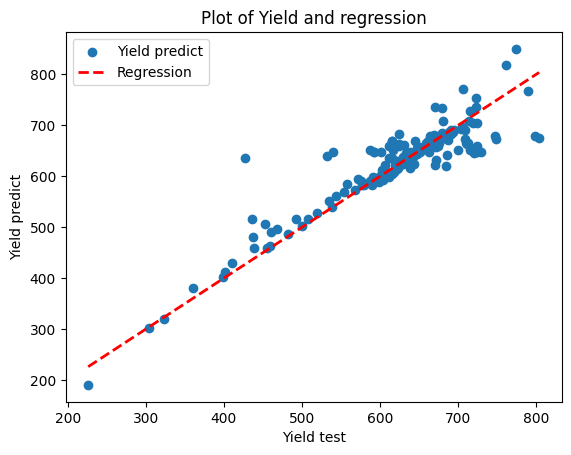

In [65]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

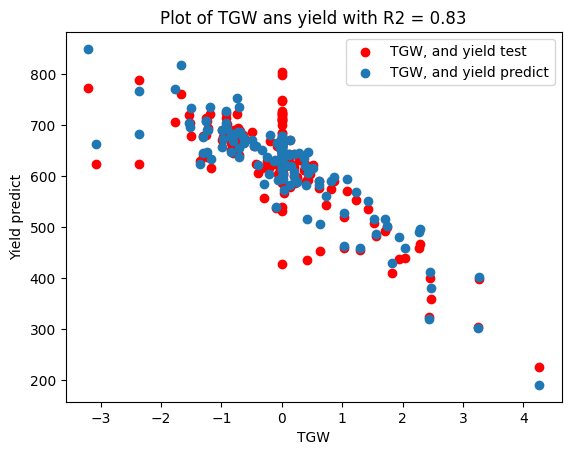

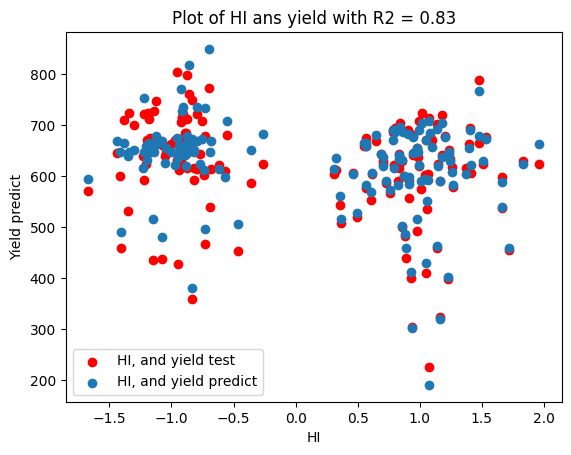

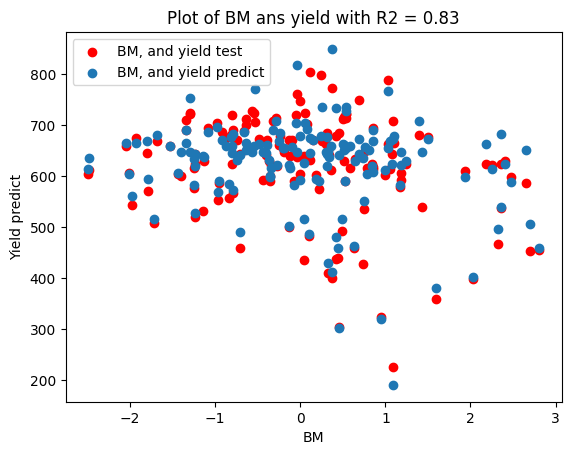

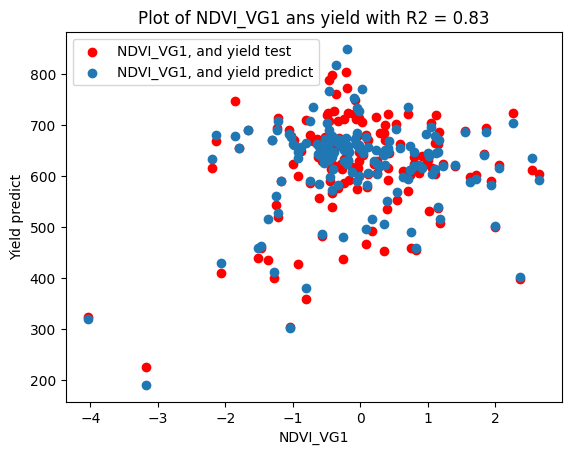

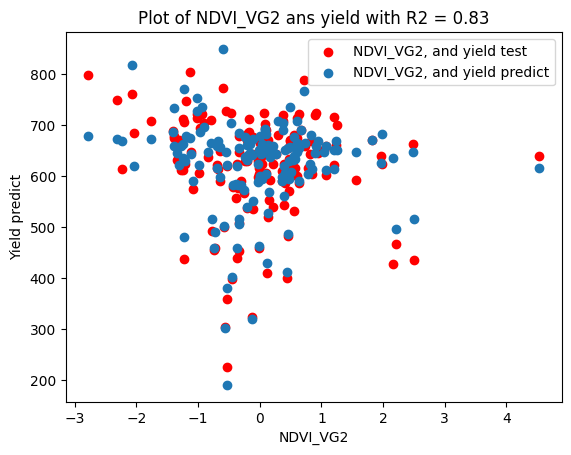

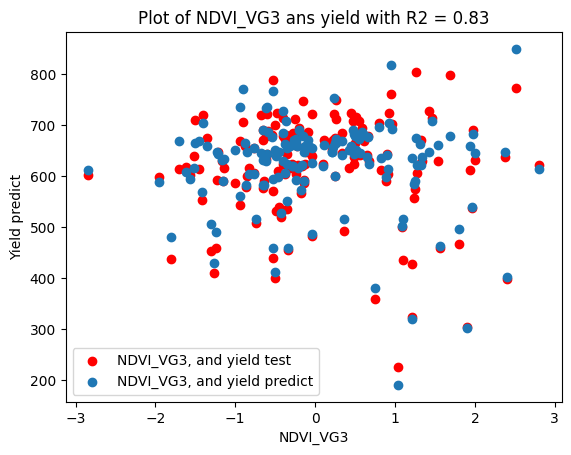

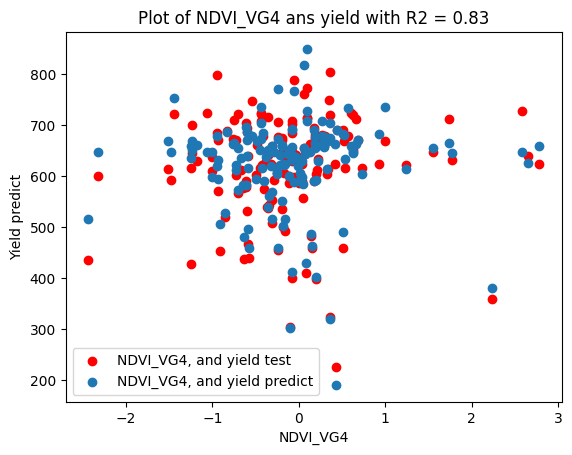

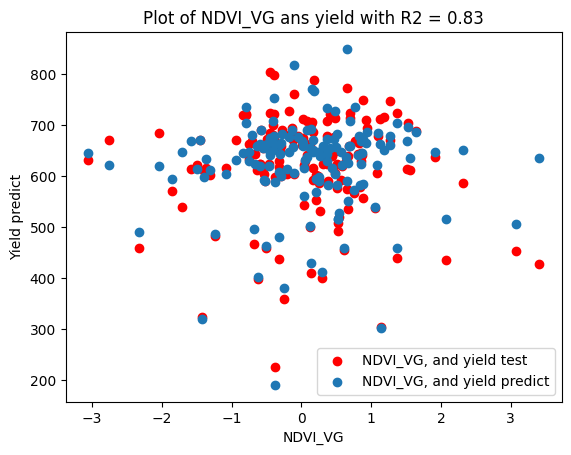

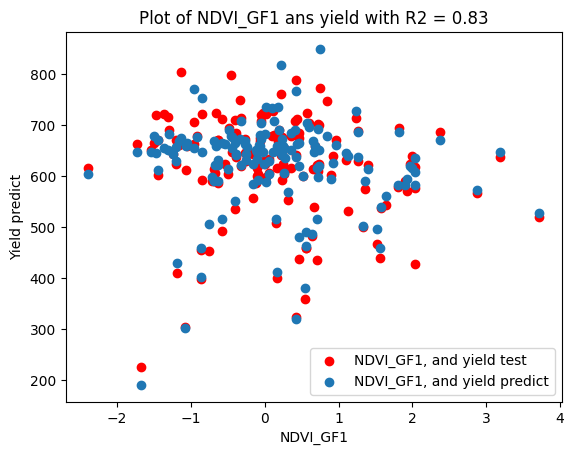

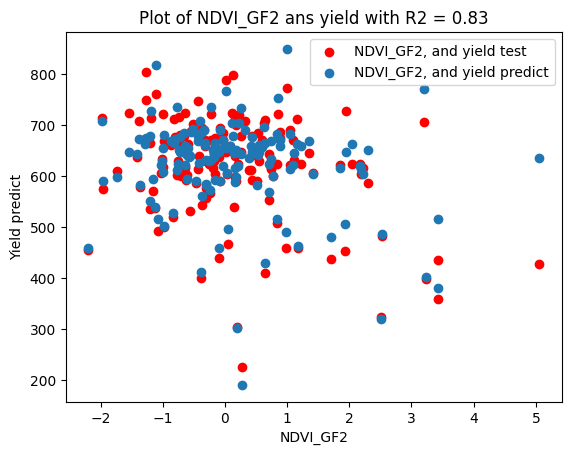

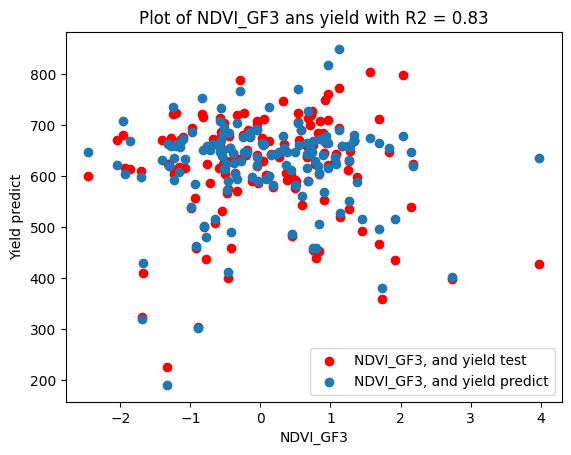

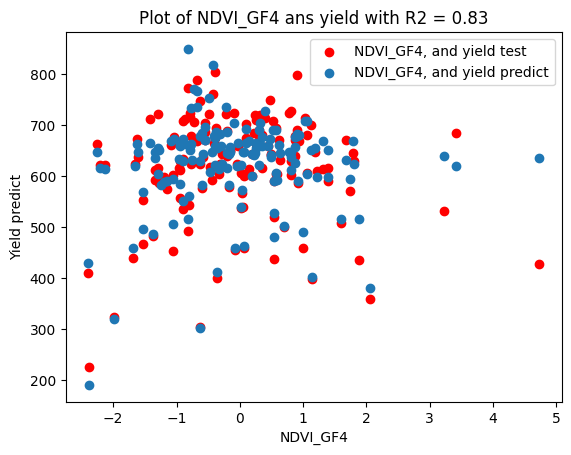

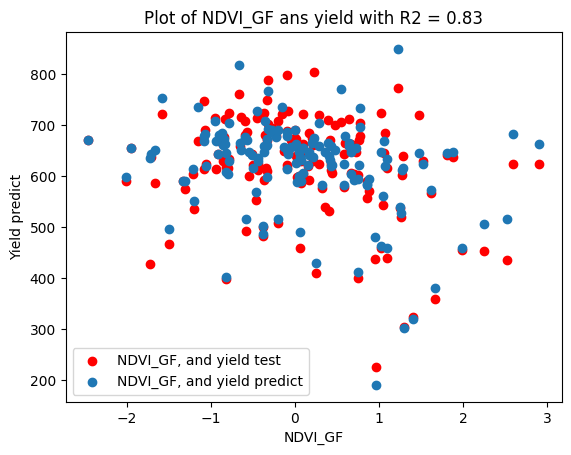

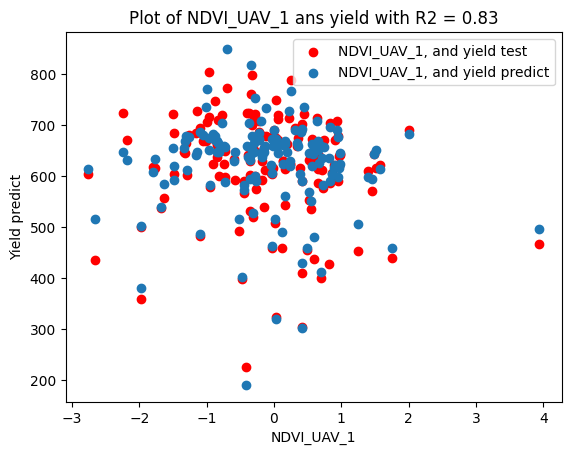

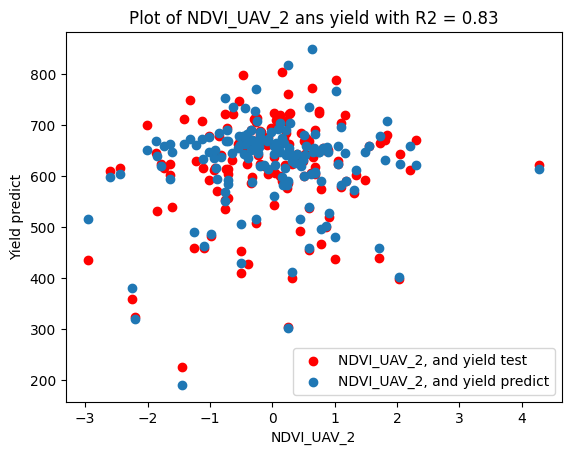

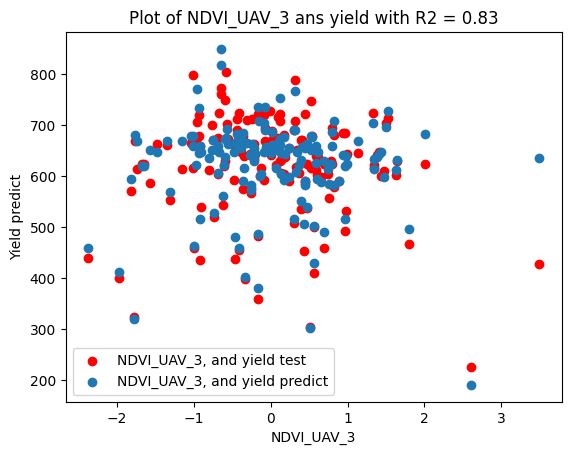

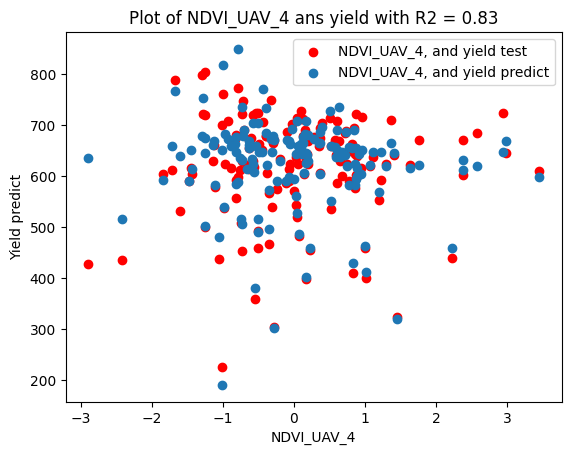

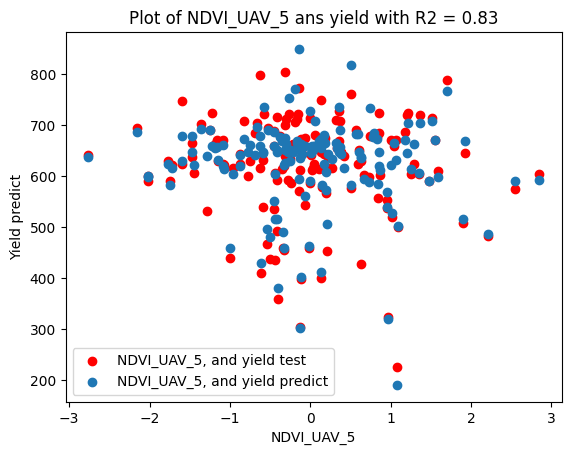

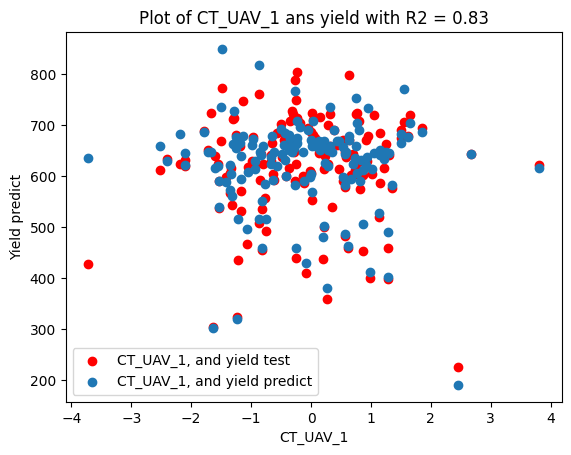

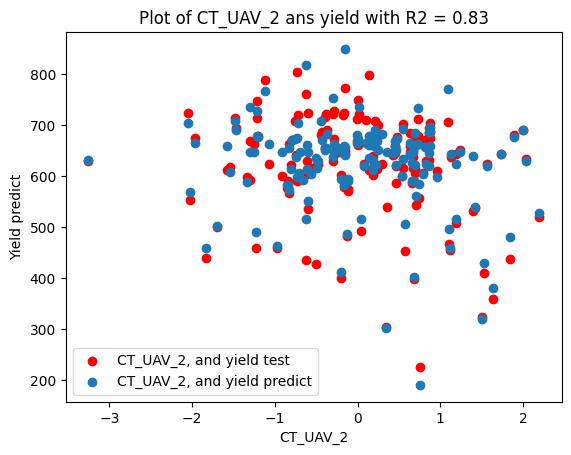

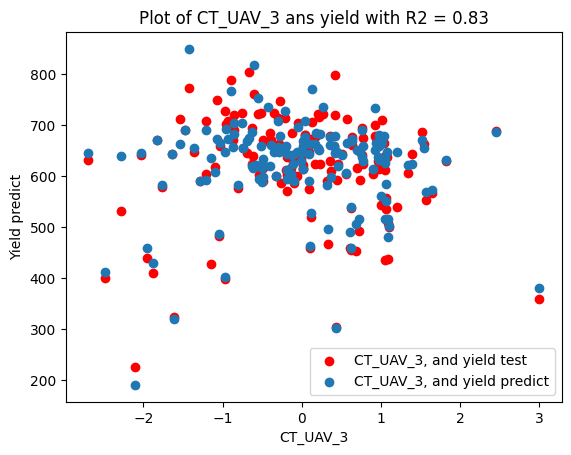

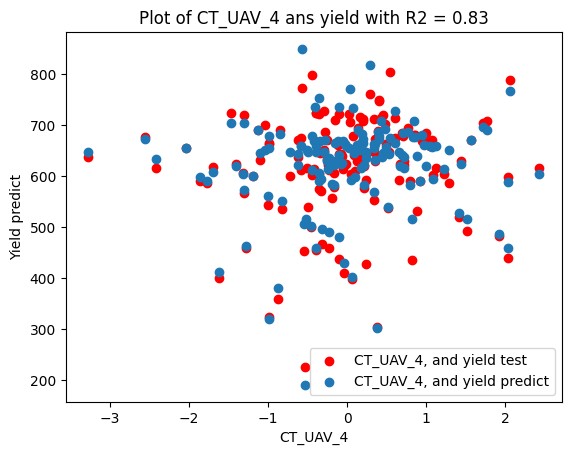

In [66]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [67]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 635.0992178539262, 'error': 0.48735179825275465},
 {'truth': 532.0, 'predict': 640.5789896004649, 'error': 0.20409584511365575},
 {'truth': 540.0, 'predict': 648.1521123002435, 'error': 0.2002816894448954},
 {'truth': 436.0, 'predict': 515.7587132059672, 'error': 0.18293282845405318},
 {'truth': 804.0, 'predict': 675.5490353742973, 'error': 0.1597648813752521},
 {'truth': 226.1118,
  'predict': 190.3208862656545,
  'error': 0.1582885711154636},
 {'truth': 799.0, 'predict': 679.4669010395685, 'error': 0.14960337792294306},
 {'truth': 453.0, 'predict': 505.7562899607587, 'error': 0.11645980123787791},
 {'truth': 587.0, 'predict': 652.2983540094968, 'error': 0.11124080751191967},
 {'truth': 729.0, 'predict': 648.4879629751781, 'error': 0.11044175174872688},
 {'truth': 724.0, 'predict': 647.3634643238362, 'error': 0.10585156861348594},
 {'truth': 720.0, 'predict': 645.2667940631599, 'error': 0.10379611935672241},
 {'truth': 749.0, 'predict': 673.0787948672468, 